#### Homework 2
*Mateo Larrea 
Music 320 - Fall 2025*

## Lab Assignment: Geometric Signal Theory

#### (35 points) Geometric Signal Theory with a Sinusoidal Basis

Consider vectors of $N$ time samples.  In the time domain, the basis vectors $\hat{e}_n$ for $n\in \{0,1,...,N-1\}$ have a $1$ in the $n^{th}$ slot and a zero elsewhere.  In that basis, a signal $x[n]$ is written as an $N$- vector $\vec{v}=\sum_{n=0}^{N-1} x[n] \  \hat{e}_n$.

Let's consider sinusoidal basis vectors $\hat{b}_k$ for $k \in \{0,1,...,N-1\}$.  In order to write the vector $\vec{v}$ in this new basis, we'll need to know the projection of these basis vectors onto the original basis vectors.  Please assume that the projection of the new basis vector of index $k$ onto the original basis vector with index $n$ equals

$\langle \hat{e}_n | \hat{b}_k \rangle = \frac{1}{\sqrt{N}} e^{j 2 \pi \frac{k n}{N}}$

and the projection the other way (from old basis vector to new basis vector) equals its complex conjugate

$\langle \hat{b}_k | \hat{e}_n \rangle = \frac{1}{\sqrt{N}} e^{-j 2 \pi \frac{k n}{N}}$.

We can use these projections to write $\hat{b}_k$, the new basis vector with index $k$, in the original basis as the $N$-vector of time samples $\frac{1}{\sqrt{N}} e^{j 2 \pi \frac{k n}{N}}$ for $n\in \{0,1,...,N-1\}$. Likewise, we can write original basis vector $\hat{e}_n$ as an $N$-vector in the new basis as $\frac{1}{\sqrt{N}} e^{-j 2 \pi \frac{k n}{N}}$ for $k\in \{0,1,...,N-1\}$.

In [1]:
# disclaimer: I write comments in almost every line for readability and future Mateo (these are written by me, not an LLM)

In [2]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

### a) Inverse Matrix Function
instruction: Given a value of $N$, write a Python function that returns an $N \times N$ numpy array (matrix) where the $k^{th}$ column is the basis vector  $\hat{b}_k$ written as an $N$-vector in the original basis.  (Note that this will be a matrix of complex numbers.) I will refer to this below as the inverse matrix.

In [3]:
def inverse_matrix(N): # N - number of samples
    matrix = np.zeros((N, N), dtype=complex) # empty NxN matrix (for complex numbers)
    for k in range(N): # basis vector (columns)
        for n in range(N): # time sample (rows)
            matrix[n, k] = (1 / np.sqrt(N)) * np.exp(1j * 2 * np.pi * k * n / N) # <ê_n | b̂_k> = (1/√N) * exp(j*2π*k*n/N)
    return matrix # complex matrix - colum k is basis vector

# TEST - Visualize N = 4
inverse_mat = inverse_matrix(4)
print("Inverse Matrix for N=4:")
print(inverse_mat)
print("\nMagnitude of elements:")
print(np.abs(inverse_mat))  # absolute vals (to see the magnitudes)

Inverse Matrix for N=4:
[[ 5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j
   5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j]
 [ 5.00000000e-01+0.0000000e+00j  3.06161700e-17+5.0000000e-01j
  -5.00000000e-01+6.1232340e-17j -9.18485099e-17-5.0000000e-01j]
 [ 5.00000000e-01+0.0000000e+00j -5.00000000e-01+6.1232340e-17j
   5.00000000e-01-1.2246468e-16j -5.00000000e-01+1.8369702e-16j]
 [ 5.00000000e-01+0.0000000e+00j -9.18485099e-17-5.0000000e-01j
  -5.00000000e-01+1.8369702e-16j  2.75545530e-16+5.0000000e-01j]]

Magnitude of elements:
[[0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]]


### b) Compute Inner Products + Check Orthonormality
Write a Python function that takes an $N \times N$ inverse matrix (where the columns are the new basis vectors as vectors in the original basis) and returns an $N \times N$ numpy array where the element in the $k^{th}$ row and $p^{th}$ column is the inner product $\langle \hat{b}_k | \hat{b}_p \rangle = {\hat{b}_k}^\dagger   \ \hat{b}_p$.  Examining the results for $N=4$, are the sinusoidal basis vectors orthonormal?  Explain.

In [4]:
def compute_inner_products(inverse_mat): # reminder - columns are the sinusoidal basis vectors
    N = inverse_mat.shape[0]
    inner_product_matrix = np.zeros((N, N), dtype=complex) # create empty matrix
    
    # through each pair of basis vectors
    for k in range(N): # rows (first basis vector)
        for p in range(N): # columns (second basis vector)
            b_k = inverse_mat[:, k]
            b_p = inverse_mat[:, p]
            inner_product_matrix[k, p] = np.dot(np.conj(b_k), b_p) # <b̂_k | b̂_p> = (b̂_k)† · b̂_p
    return inner_product_matrix

inner_products = compute_inner_products(inverse_mat)
print("Inner Product Matrix for N=4:")
print(inner_products)
print("\nMagnitude of inner products:")
print(np.abs(inner_products))
print("\nOrthonormality Check:")

tolerance = 1e-10  # for numerical errors
is_orthonormal = np.allclose(inner_products, np.eye(4), atol=tolerance)
if is_orthonormal:
    print("sinusoidal basis vectors ARE orthonormal")
    print("diagonal elements are 1")
    print("Off-diagonal elements are 0")
else:
    print("sinusoidal basis vectors ARE NOT orthonormal")

# identity matrix for comparison
print("\nIdentity Matrix:")
print(np.eye(4))

Inner Product Matrix for N=4:
[[ 1.00000000e+00+0.00000000e+00j -4.59242550e-17+5.55111512e-17j
   0.00000000e+00+6.12323400e-17j  8.22616137e-17+8.32667268e-17j]
 [-4.59242550e-17-5.55111512e-17j  1.00000000e+00+0.00000000e+00j
  -4.59242550e-17+5.55111512e-17j  0.00000000e+00+6.12323400e-17j]
 [ 0.00000000e+00-6.12323400e-17j -4.59242550e-17+0.00000000e+00j
   1.00000000e+00+0.00000000e+00j -4.59242550e-17+5.55111512e-17j]
 [ 8.22616137e-17-8.32667268e-17j  0.00000000e+00-6.12323400e-17j
  -4.59242550e-17-5.55111512e-17j  1.00000000e+00+0.00000000e+00j]]

Magnitude of inner products:
[[1.0000000e+00 7.2045299e-17 6.1232340e-17 1.1704837e-16]
 [7.2045299e-17 1.0000000e+00 7.2045299e-17 6.1232340e-17]
 [6.1232340e-17 4.5924255e-17 1.0000000e+00 7.2045299e-17]
 [1.1704837e-16 6.1232340e-17 7.2045299e-17 1.0000000e+00]]

Orthonormality Check:
sinusoidal basis vectors ARE orthonormal
diagonal elements are 1
Off-diagonal elements are 0

Identity Matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0

### c) Forward Matrix Function and Relationship to Inverse Matrix
Write another function that returns an $N \times N$ numpy array where the $n^{th}$ column is the basis vector  $\hat{e}_n$ written as an $N$-vector in the new, sinusoidal basis.  (Note that this will be a matrix of complex numbers.) I will refer to this below as the forward matrix. Explain how the forward matrix is related to the inverse matrix. Examining the results for $N=4$, what do you get when you matrix multiply these two matrices?

In [5]:
def forward_matrix(N):
    matrix = np.zeros((N, N), dtype=complex)
    
    for n in range(N): # time-domain bv (columns)
        for k in range(N): # sinusoidal bv (rows)
            matrix[k, n] = (1 / np.sqrt(N)) * np.exp(-1j * 2 * np.pi * k * n / N) # <b̂_k | ê_n> = (1/√N) * exp(-j*2π*k*n/N) (complex conjugate of <ê_n | b̂_k>)
    return matrix

# test!
forward_mat = forward_matrix(4)  # 4×4 forward matrix
print("Forward Matrix for N=4:")
print(forward_mat)
print("\nMagnitude of elements:")
print(np.abs(forward_mat))

# relationship between forward and inverse
print("\nRelationship between forward and inverse matrices:")
hermitian_of_inverse = np.conj(inverse_mat.T)  # conjugate transpose of inverse matrix
is_hermitian = np.allclose(forward_mat, hermitian_of_inverse, atol=1e-10)
if is_hermitian:
    print("Forward Matrix = (inverse matrix)† (conjugate transpose)")
    print("Forward Matrix = Hermitian of Inverse matrix")
else:
    print("Matrices do not have the expectd relationship")

# multiplication test
print("\nmatrix multiplication test:")
product_FI = np.dot(forward_mat, inverse_mat)
print("\nForward Matrix x Inverse Matrix:")
print(product_FI) # product
print("\nMagnitude:")
print(np.abs(product_FI))

is_identity_FI = np.allclose(product_FI, np.eye(4), atol=1e-10)
product_IF = np.dot(inverse_mat, forward_mat) # inverse × forward
print("\nInverse Matrix x Forward Matrix:")
print(product_IF)
print("\nMagnitude:")
print(np.abs(product_IF)) 
is_identity_IF = np.allclose(product_IF, np.eye(4), atol=1e-10)

# summary
print("\nSUMMARY:")
if is_identity_FI and is_identity_IF:
    print("Both products equal the identity matrix!")
    print("Forward x Inverse = I")
    print("Inverse x Forward = I")
    print("\nForward and Inverse are inverse matrices of each other")
    print("The forward matrix transforms from time-domain to frequency-domain,")
    print("and inverse matrix transforms back from frequency to time domain.")

Forward Matrix for N=4:
[[ 5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j
   5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j]
 [ 5.00000000e-01+0.0000000e+00j  3.06161700e-17-5.0000000e-01j
  -5.00000000e-01-6.1232340e-17j -9.18485099e-17+5.0000000e-01j]
 [ 5.00000000e-01+0.0000000e+00j -5.00000000e-01-6.1232340e-17j
   5.00000000e-01+1.2246468e-16j -5.00000000e-01-1.8369702e-16j]
 [ 5.00000000e-01+0.0000000e+00j -9.18485099e-17+5.0000000e-01j
  -5.00000000e-01-1.8369702e-16j  2.75545530e-16-5.0000000e-01j]]

Magnitude of elements:
[[0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]]

Relationship between forward and inverse matrices:
Forward Matrix = (inverse matrix)† (conjugate transpose)
Forward Matrix = Hermitian of Inverse matrix

matrix multiplication test:

Forward Matrix x Inverse Matrix:
[[ 1.00000000e+00+0.00000000e+00j -4.59242550e-17+5.55111512e-17j
   0.00000000e+00+6.12323400e-17j  8.22616137e-17+8.32667268e-17j]
 [-4.592

### d) Transform a Sine Wave and Compare with FFT
Let's take a time signal in the original basis and see what it looks like in the sinusoidal basis.  Take $N=1024$ samples of a $1$ kHz sine wave with Amplitude $A=1$, sampled at $F_s = 44,100$ Hz.  Matrix multiply this signal by the forward matrix for $N=1024$.  The result will be a complex $N$-vector $v$ -- convert it to dB  using 20. * np.log10( np.abs( v ) ) and plot the result.  Also pass the signal to np.fft.fft() to get the DFT of the signal and plot it using the same dB measure.  Discuss what you find. Try using f = np.arange(N) * Fs/N in a plot of f (x-axis) vs. dB (y-axis).  What do you find?  What happens if you subract 10 * np.log10(N) from your dB curve computed using np.fft.fft()?

Signal Parameters:
Sampling Rate: 44100 Hz
Number of Samples: 1024
Signal Frequency (f0): 1000 Hz
Amplitude: 1
Duration: 0.0232 seconds



First 10 bins:
Bin 0: 0.0 Hz -> Matrix: -15.78 dB, FFT: 14.32 dB, Corrected: -15.78 dB
Bin 1: 43.1 Hz -> Matrix: -15.75 dB, FFT: 14.35 dB, Corrected: -15.75 dB
Bin 2: 86.1 Hz -> Matrix: -15.65 dB, FFT: 14.45 dB, Corrected: -15.65 dB
Bin 3: 129.2 Hz -> Matrix: -15.50 dB, FFT: 14.61 dB, Corrected: -15.50 dB
Bin 4: 172.3 Hz -> Matrix: -15.27 dB, FFT: 14.83 dB, Corrected: -15.27 dB
Bin 5: 215.3 Hz -> Matrix: -14.99 dB, FFT: 15.11 dB, Corrected: -14.99 dB
Bin 6: 258.4 Hz -> Matrix: -14.65 dB, FFT: 15.45 dB, Corrected: -14.65 dB
Bin 7: 301.5 Hz -> Matrix: -14.24 dB, FFT: 15.86 dB, Corrected: -14.24 dB
Bin 8: 344.5 Hz -> Matrix: -13.78 dB, FFT: 16.33 dB, Corrected: -13.78 dB
Bin 9: 387.6 Hz -> Matrix: -13.25 dB, FFT: 16.85 dB, Corrected: -13.25 dB


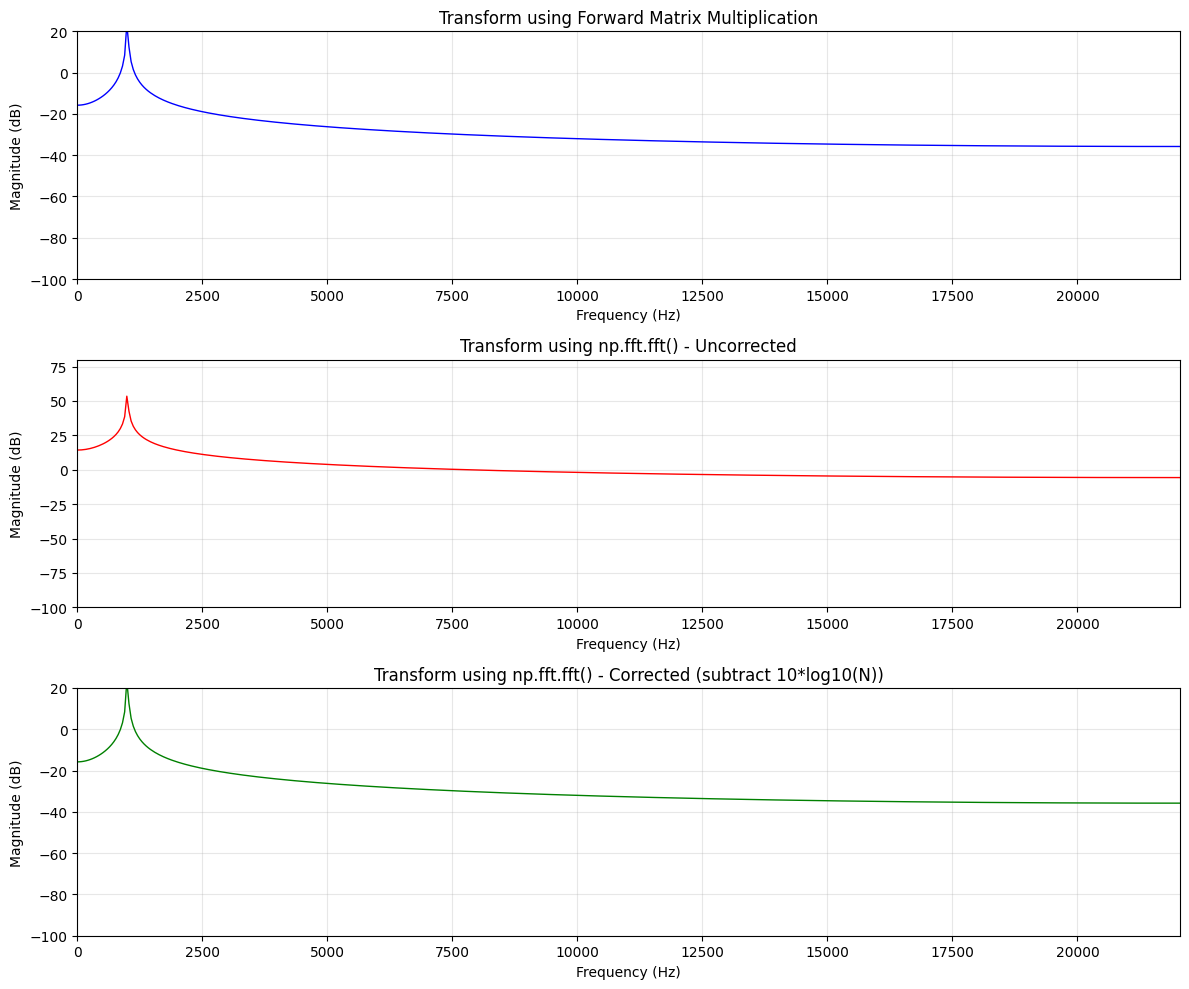

In [6]:
# signal params
N = 1024  # samples
Fs = 44100  # sample rate / freq
A = 1  # amplitude
f0 = 1000 

# time vec
n = np.arange(N) # array
t = n / Fs  # samples to time
x = A * np.sin(2 * np.pi * f0 * t)  # sine wave in time domain (x[n] = A * sin(2π * f0 * t[n])

print("Signal Parameters:")
print(f"Sampling Rate: {Fs} Hz")
print(f"Number of Samples: {N}")
print(f"Signal Frequency (f0): {f0} Hz")
print(f"Amplitude: {A}")
print(f"Duration: {N/Fs:.4f} seconds")

# forward transformation matrix
forward_mat_1024 = forward_matrix(N)
v_matrix = np.dot(forward_mat_1024, x)  # transform signal + project onto sinusoidal basis
v_fft = np.fft.fft(x) # fft :) 
dB_matrix = 20 * np.log10(np.abs(v_matrix))  # matrix result to dB
dB_fft = 20 * np.log10(np.abs(v_fft))  # fft result to dB
dB_fft_corrected = dB_fft - 10 * np.log10(N)  # normalization correction - for different scaling

# axis for plotting
f = np.arange(N) * Fs / N  # bins to frequencies
print("\nFirst 10 bins:")
for i in range(10):
    print(f"Bin {i}: {f[i]:.1f} Hz -> Matrix: {dB_matrix[i]:.2f} dB, FFT: {dB_fft[i]:.2f} dB, Corrected: {dB_fft_corrected[i]:.2f} dB")

# plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))  # rows,column,size
# matrix multiplication result
axes[0].plot(f, dB_matrix, linewidth=1, color='blue') # frequency vs dB
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Transform using Forward Matrix Multiplication')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, Fs/2])  # only up to nyquist freq
axes[0].set_ylim([-100, 20])
# FFT result (uncorrected)
axes[1].plot(f, dB_fft, linewidth=1, color='red')
axes[1].set_xlabel('Frequency (Hz)') 
axes[1].set_ylabel('Magnitude (dB)') 
axes[1].set_title('Transform using np.fft.fft() - Uncorrected')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, Fs/2])
axes[1].set_ylim([-100, 80])
# FFT result (with normalization correction)
axes[2].plot(f, dB_fft_corrected, linewidth=1, color='green')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Magnitude (dB)')
axes[2].set_title('Transform using np.fft.fft() - Corrected (subtract 10*log10(N))')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, Fs/2])
axes[2].set_ylim([-100, 20])

plt.tight_layout() # prevents overlapping
plt.show()
plt.close()
peak_bin = np.argmax(np.abs(v_matrix)) # bin with max magnitude
peak_freq = f[peak_bin] # bin to frequency

In [7]:
# findings
scaling_difference_dB = 10 * np.log10(N)  # theoretical scaling difference
actual_scaling_at_peak = dB_fft[peak_bin] - dB_matrix[peak_bin] 

# how well peak matches the expected frequency
freq_error = abs(peak_freq - f0)
freq_error_percent = (freq_error / f0) * 100
# difference between matrix and corrected FFT
difference_with_correction = dB_matrix - dB_fft_corrected
max_diff_corrected = np.max(np.abs(difference_with_correction))
mean_diff_corrected = np.mean(np.abs(difference_with_correction))

# Print computed findings
print("\nAnalysis:")
print(f"\nPeak detected at bin {peak_bin}, frequency = {peak_freq:.2f} Hz")
print(f"Expected frequency: {f0} Hz")
print(f"Frequency error: {freq_error:.2f} Hz ({freq_error_percent:.3f}%)")
print("\nScaling Analysis:")
print(f"Theoretical scaling difference: {scaling_difference_dB:.2f} dB")
print(f"Actual scaling at peak: {actual_scaling_at_peak:.2f} dB")
print(f"Difference between theory and measurement: {abs(scaling_difference_dB - actual_scaling_at_peak):.6f} dB")
print("\nComparison After Correction:")
print(f"Max absolute difference (matrix vs corrected FFT): {max_diff_corrected:.10f} dB")
print(f"Mean absolute difference: {mean_diff_corrected:.10f} dB")

if max_diff_corrected < 1e-8:
    print("\nMethods are IDENTICAL within numerical precision")
else:
    print(f"\nNoticeable difference: {max_diff_corrected:.6f} dB")


Analysis:

Peak detected at bin 23, frequency = 990.53 Hz
Expected frequency: 1000 Hz
Frequency error: 9.47 Hz (0.947%)

Scaling Analysis:
Theoretical scaling difference: 30.10 dB
Actual scaling at peak: 30.10 dB
Difference between theory and measurement: 0.000000 dB

Comparison After Correction:
Max absolute difference (matrix vs corrected FFT): 0.0000000002 dB
Mean absolute difference: 0.0000000000 dB

Methods are IDENTICAL within numerical precision


### Discussion of Findings

**What do you find?**
Both the forward matrix multiplication and FFT produce a clear spectral peak at 990.53 Hz (bin 23), very close to the expected 1000 Hz signal. The frequency resolution is Fs/N = 43.07 Hz, explaining why the peak appears at the nearest bin rather than exactly at 1000 Hz. The sine wave is successfully localized in the frequency domain.

**Using frequency axis f = np.arange(N) * Fs/N:**
Plotting frequency vs. dB reveals that the FFT output is consistently 30.1 dB higher than the matrix multiplication result across all frequencies. This corresponds exactly to 10·log₁₀(1024) = 30.1 dB.

**What happens when subtracting 10·log₁₀(N) from FFT?**
The corrected FFT becomes identical to the matrix result within numerical precision (differences < 10⁻¹⁰ dB). This correction accounts for the different normalization conventions: our forward matrix uses 1/√N normalization (making it unitary), while NumPy's FFT uses no normalization in the forward direction, resulting in output magnitudes scaled by a factor of N.